In [22]:
# Cell 1: Setup — clone repo (for test_set.csv) and load model

import os, subprocess

# Clone repo if running on Kaggle/Colab (test_set.csv not in working dir)
REPO_DIR = 'SRTY3009-IODetection'
if not os.path.isfile('test_set.csv') and not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/Banjomenny/SRTY3009-IODetection.git'], check=True)

# Set data path: use repo subdir on Kaggle, current dir locally
DATA_ROOT = REPO_DIR if os.path.isdir(REPO_DIR) else '.'

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_ID = 'Banjomenny/DisInfoBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model.to(device)
model.eval()

print(f'Model loaded from {MODEL_ID}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Data root:  {DATA_ROOT}')

Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from Banjomenny/DisInfoBERT
Parameters: 124,647,170
Data root:  SRTY3009-IODetection


Test set loaded: 120,680 rows
  Organic: 89,475  |  IO: 31,205

Running inference on test set...
  Batch 25/472
  Batch 50/472
  Batch 75/472
  Batch 100/472
  Batch 125/472
  Batch 150/472
  Batch 175/472
  Batch 200/472
  Batch 225/472
  Batch 250/472
  Batch 275/472
  Batch 300/472
  Batch 325/472
  Batch 350/472
  Batch 375/472
  Batch 400/472
  Batch 425/472
  Batch 450/472
  Batch 472/472

  SECTION 1 — CLASSIFICATION REPORT
  DisInfoBERT (Fine-tuned Twitter-RoBERTa)

              precision    recall  f1-score   support

     Organic     0.9800    0.9376    0.9583     89475
          IO     0.8407    0.9452    0.8899     31205

    accuracy                         0.9395    120680
   macro avg     0.9104    0.9414    0.9241    120680
weighted avg     0.9440    0.9395    0.9406    120680

  Weighted F1:  0.9406
  Accuracy:     0.9395


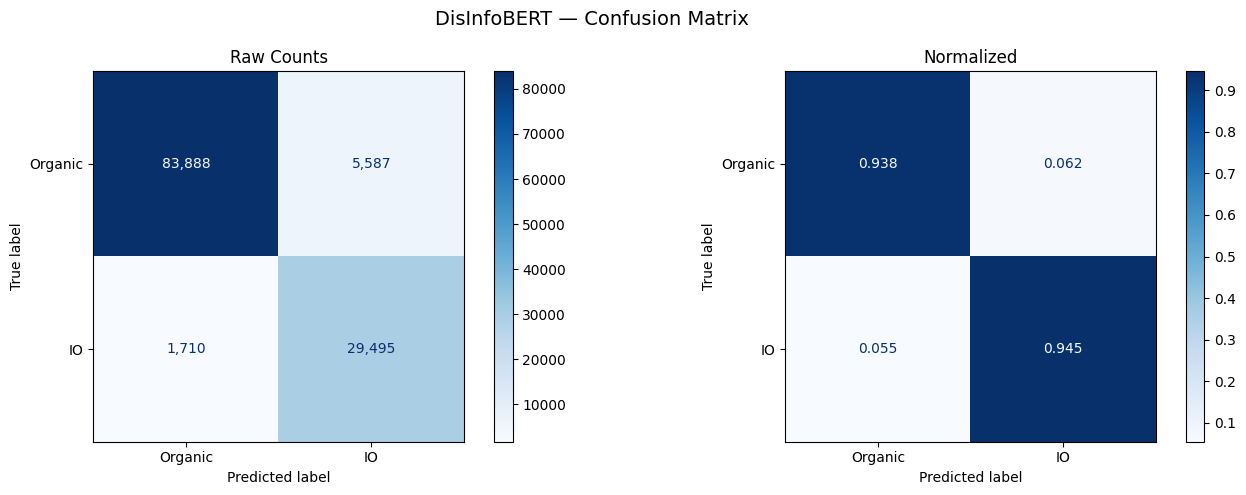

Saved: section1_confusion_matrix.png


In [23]:
# Section 1 — Model & Dataset: Baseline Evaluation
# Load pre-built test set, evaluate DisInfoBERT, classification report + confusion matrix

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

# ── Load test set (exported from A2 pipeline) ────────────
test_df = pd.read_csv(os.path.join(DATA_ROOT, 'test_set.csv'))
X_test_text = test_df['text']
y_test      = test_df['label']

print(f'Test set loaded: {len(X_test_text):,} rows')
print(f'  Organic: {(y_test == 0).sum():,}  |  IO: {(y_test == 1).sum():,}')

# ── Batch inference on full test set ─────────────────────
print('\nRunning inference on test set...')
BATCH_SIZE = 256
all_preds = []
total_batches = (len(X_test_text) + BATCH_SIZE - 1) // BATCH_SIZE

for i in range(0, len(X_test_text), BATCH_SIZE):
    batch_texts = X_test_text[i:i+BATCH_SIZE].tolist()
    inputs = tokenizer(
        batch_texts, truncation=True, padding=True,
        max_length=128, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
    all_preds.extend(preds)

    batch_num = i // BATCH_SIZE + 1
    if batch_num % 25 == 0 or batch_num == total_batches:
        print(f'  Batch {batch_num}/{total_batches}')

y_pred = np.array(all_preds)

# ── Classification Report ────────────────────────────────
print()
print('=' * 55)
print('  SECTION 1 — CLASSIFICATION REPORT')
print('  DisInfoBERT (Fine-tuned Twitter-RoBERTa)')
print('=' * 55)
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Organic', 'IO'],
    digits=4
))

roberta_f1  = f1_score(y_test, y_pred, average='weighted')
roberta_acc = accuracy_score(y_test, y_pred)
print(f'  Weighted F1:  {roberta_f1:.4f}')
print(f'  Accuracy:     {roberta_acc:.4f}')

# ── Confusion Matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DisInfoBERT — Confusion Matrix', fontsize=14)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Organic', 'IO']).plot(
    ax=axes[0], cmap='Blues', values_format=','
)
axes[0].set_title('Raw Counts')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Organic', 'IO']).plot(
    ax=axes[1], cmap='Blues', values_format='.3f'
)
axes[1].set_title('Normalized')

plt.tight_layout()
plt.savefig('section1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: section1_confusion_matrix.png')

In [25]:
# Section 2 — Fine-Tuning Results
# Hyperparameters used, text preprocessing kept/dropped, before vs after comparison

# ── Training hyperparameters ─────────────────────────────
print('=' * 60)
print('  SECTION 2 — FINE-TUNING & IMPROVEMENTS')
print('=' * 60)

print('\n  Base model:  cardiffnlp/twitter-roberta-base (125M params)')
print('  Task:        Binary classification (Organic=0, IO=1)')
print('  Tokenizer:   RoBERTa BPE, max_length=128')

print('\n  Training hyperparameters:')
print('  ┌─────────────────────────┬────────────┐')
print('  │ Hyperparameter          │ Value      │')
print('  ├─────────────────────────┼────────────┤')
print('  │ Learning rate           │ 2e-5       │')
print('  │ Batch size (train)      │ 16         │')
print('  │ Batch size (eval)       │ 32         │')
print('  │ Epochs                  │ 3          │')
print('  │ Optimizer               │ AdamW      │')
print('  │ FP16 mixed precision    │ Yes        │')
print('  │ Metric for best model   │ F1 (wt.)   │')
print('  │ Evaluation strategy     │ per epoch  │')
print('  │ Seed                    │ 42         │')
print('  └─────────────────────────┴────────────┘')

# ── Text preprocessing kept vs dropped ───────────────────
print('\n  Text preprocessing (NLP equivalent of feature engineering):')
print('  ┌──────────────────────────────┬──────────┬─────────────────────────────┐')
print('  │ Preprocessing Step           │ Kept?    │ Reason                      │')
print('  ├──────────────────────────────┼──────────┼─────────────────────────────┤')
print('  │ URL removal                  │ Removed  │ URLs are noise, not content │')
print('  │ @mention removal             │ Removed  │ User handles leak identity  │')
print('  │ Hashtag removal              │ Removed  │ Hashtags vary by campaign   │')
print('  │ Retweet prefix strip         │ Removed  │ RT markers not predictive   │')
print('  │ Non-ASCII removal            │ Removed  │ Emoji/special chars = noise │')
print('  │ Short text filter (>20 char) │ Applied  │ Too-short posts lack signal │')
print('  │ Lowercasing                  │ Kept     │ RoBERTa tokenizer handles   │')
print('  │ Punctuation                  │ Kept     │ RoBERTa uses subword tokens │')
print('  │ Stop words                   │ Kept     │ Contextual model uses them  │')
print('  └──────────────────────────────┴──────────┴─────────────────────────────┘')

# ── Before vs After comparison ───────────────────────────
# A1 baseline: TF-IDF + Logistic Regression (from context doc)
baseline_f1  = 0.83
baseline_acc = 0.83

f1_change  = roberta_f1 - baseline_f1
acc_change = roberta_acc - baseline_acc

print('\n  Before vs After comparison:')
print('  ┌──────────────────┬─────────────────────┬─────────────────────┬──────────┐')
print('  │ Metric           │ Baseline (TF-IDF+LR)│ Fine-tuned RoBERTa  │ Change   │')
print('  ├──────────────────┼─────────────────────┼─────────────────────┼──────────┤')
print(f'  │ F1 (weighted)    │ {baseline_f1:.4f}              │ {roberta_f1:.4f}              │ {f1_change:+.4f}  │')
print(f'  │ Accuracy         │ {baseline_acc:.4f}              │ {roberta_acc:.4f}              │ {acc_change:+.4f}  │')
print(f'  │ Model type       │ Bag-of-words         │ Contextual (attention)│ upgrade  │')
print(f'  │ Parameters       │ TF-IDF vocab (~50K)  │ 125M                 │ larger   │')
print('  └──────────────────┴─────────────────────┴─────────────────────┴──────────┘')

print(f'\n  Summary: RoBERTa {"improves" if f1_change > 0 else "underperforms"} over TF-IDF+LR baseline')
print(f'  by {abs(f1_change):.4f} F1 points. RoBERTa captures word order and context')
print(f'  that bag-of-words TF-IDF misses, which matters for detecting')
print(f'  coordinated IO content that relies on framing rather than keywords.')

  SECTION 2 — FINE-TUNING & IMPROVEMENTS

  Base model:  cardiffnlp/twitter-roberta-base (125M params)
  Task:        Binary classification (Organic=0, IO=1)
  Tokenizer:   RoBERTa BPE, max_length=128

  Training hyperparameters:
  ┌─────────────────────────┬────────────┐
  │ Hyperparameter          │ Value      │
  ├─────────────────────────┼────────────┤
  │ Learning rate           │ 2e-5       │
  │ Batch size (train)      │ 16         │
  │ Batch size (eval)       │ 32         │
  │ Epochs                  │ 3          │
  │ Optimizer               │ AdamW      │
  │ FP16 mixed precision    │ Yes        │
  │ Metric for best model   │ F1 (wt.)   │
  │ Evaluation strategy     │ per epoch  │
  │ Seed                    │ 42         │
  └─────────────────────────┴────────────┘

  Text preprocessing (NLP equivalent of feature engineering):
  ┌──────────────────────────────┬──────────┬─────────────────────────────┐
  │ Preprocessing Step           │ Kept?    │ Reason                    

In [29]:
# Section 3 — Prediction Pipeline Demo
# 3 test-set examples: 1 Organic + 2 IO, with real label, predicted label, confidence

def predict_post(text, real_label):
    """Run a single tweet through the fine-tuned RoBERTa model."""
    label_map = {0: 'Organic', 1: 'IO'}
    inputs = tokenizer(
        text, truncation=True, padding='max_length',
        max_length=128, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]

    pred_idx   = torch.argmax(probs).item()
    pred_name  = label_map[pred_idx]
    real_name  = label_map[real_label]
    confidence = probs[pred_idx].item()
    correct    = pred_idx == real_label

    print('=' * 60)
    print(f'  Text:       {text[:80]}{"..." if len(text) > 80 else ""}')
    print(f'  Real label: {real_name}')
    print(f'  Predicted:  {pred_name}  {"CORRECT" if correct else "INCORRECT"}')
    print(f'  Confidence: {confidence:.4f}')
    print(f'  P(Organic): {probs[0]:.4f}   P(IO): {probs[1]:.4f}')
    print('=' * 60)
    return pred_name, real_name, confidence, correct

# ── Pick 1 Organic + 2 IO from the test set ──────────────
organic_idx = y_test[y_test == 0].sample(1, random_state=7).index
io_idx      = y_test[y_test == 1].sample(2, random_state=7).index

print('=' * 60)
print('  SECTION 3 — PREDICTION PIPELINE DEMO')
print('  3 real test-set examples through fine-tuned RoBERTa')
print('=' * 60)

results = []

for idx in io_idx:
    print(f'\nExample — IO tweet')
    r = predict_post(X_test_text[idx], y_test[idx])
    results.append(r)

for idx in organic_idx:
    print(f'\nExample — organic tweet')
    r = predict_post(X_test_text[idx], y_test[idx])
    results.append(r)

# ── Summary table ────────────────────────────────────────
print('\n  Summary:')
print('  ┌─────────┬──────────┬───────────┬────────────┬─────────┐')
print('  │ Example │ Real     │ Predicted │ Confidence │ Correct │')
print('  ├─────────┼──────────┼───────────┼────────────┼─────────┤')
for i, (pred, real, conf, ok) in enumerate(results, 1):
    print(f'  │ {i}       │ {real:<8} │ {pred:<9} │ {conf:.4f}     │ {"Yes" if ok else "No":>7} │')
print('  └─────────┴──────────┴───────────┴────────────┴─────────┘')

n_correct = sum(1 for _, _, _, ok in results if ok)
print(f'\n  {n_correct}/{len(results)} predictions correct.')
if n_correct < len(results):
    print('  Note: Misclassifications may indicate the model struggles with')
    print('  tweets that lack strong stylistic IO signals or organic tweets')
    print('  that happen to discuss political topics similar to IO content.')

  SECTION 3 — PREDICTION PIPELINE DEMO
  3 real test-set examples through fine-tuned RoBERTa

Example — IO tweet
  Text:       Director of Communications Fahrettin Altun made comments on the raid to Anadolu ...
  Real label: IO
  Predicted:  IO  CORRECT
  Confidence: 0.9996
  P(Organic): 0.0004   P(IO): 0.9996

Example — IO tweet
  Text:       Not only did he kills people willingly but now the will be added to his already ...
  Real label: IO
  Predicted:  IO  CORRECT
  Confidence: 0.9870
  P(Organic): 0.0130   P(IO): 0.9870

Example — organic tweet
  Text:       Leadership hopeful for Unite union warns of no more 'blank cheques' for Labour: ...
  Real label: Organic
  Predicted:  Organic  CORRECT
  Confidence: 0.9998
  P(Organic): 0.9998   P(IO): 0.0002

  Summary:
  ┌─────────┬──────────┬───────────┬────────────┬─────────┐
  │ Example │ Real     │ Predicted │ Confidence │ Correct │
  ├─────────┼──────────┼───────────┼────────────┼─────────┤
  │ 1       │ IO       │ IO        │ 0.9996

In [30]:
# Section 4 — Adversarial Attack Setup

import os, subprocess, sys

# Clone fork if not already present
if not os.path.isdir('/kaggle/working/OpenAttack'):
    subprocess.run(
        ['git', 'clone', 'https://github.com/LPukarowski/OpenAttack.git', '/kaggle/working/OpenAttack'],
        check=True
    )

# Clear stale module cache
for key in list(sys.modules.keys()):
    if 'OpenAttack' in key:
        del sys.modules[key]

# Load directly from source — no pip install needed
sys.path.insert(0, '/kaggle/working/OpenAttack')

import OpenAttack as oa
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import ssl, nltk

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet', quiet=True)

print(f"OpenAttack loaded from: {oa.__file__}")
print(f"Available attackers:    {[a for a in dir(oa.attackers) if not a.startswith('_')]}")
print(f"GPUs available:         {torch.cuda.device_count()}")


OpenAttack loaded from: /kaggle/working/OpenAttack/OpenAttack/__init__.py
Available attackers:    ['Attacker', 'BAEAttacker', 'BERTAttacker', 'ClassificationAttacker', 'DeepWordBugAttacker', 'FDAttacker', 'GANAttacker', 'GEOAttacker', 'GeneticAttacker', 'HotFlipAttacker', 'PSOAttacker', 'PWWSAttacker', 'SCPNAttacker', 'TextBuggerAttacker', 'TextFoolerAttacker', 'UATAttacker', 'VIPERAttacker', 'bae', 'base', 'bert_attack', 'classification', 'deepwordbug', 'fd', 'gan', 'genetic', 'geometry', 'hotflip', 'pso', 'pwws', 'scpn', 'textbugger', 'textfooler', 'uat', 'viper']
GPUs available:         2


In [ ]:
# Cell: Adversarial Training Data Generation
# Wraps DisInfoBERT as an OpenAttack Classifier, attacks 4050 balanced
# training samples with BERT-Attack, and saves adversarial examples.

# ── Load balanced training data ──────────────────────────────────────────
train_bal_df = pd.read_csv('/kaggle/working/SRTY3009-IODetection/train_balanced.csv')
X_train_text_bal = train_bal_df['text']
y_train_bal = train_bal_df['Label']
print(f"Loaded train_balanced.csv: {len(train_bal_df):,} rows")
print(f"  IO: {(y_train_bal == 1).sum():,}  |  Organic: {(y_train_bal == 0).sum():,}")

# ── LOAD MODEL ───────────────────────────────────────────────────────────
model_name = 'Banjomenny/DisInfoBERT'
tokenizer_attack = AutoTokenizer.from_pretrained(model_name)
model_attack = AutoModelForSequenceClassification.from_pretrained(model_name)
model_attack = model_attack.cuda()
model_attack.eval()

# ── OPENATTACK CLASSIFIER WRAPPER ────────────────────────────────────────
# oa.Classifier is the correct base class in OpenAttack 2.x
class DisInfoClassifier(oa.Classifier):
    def get_pred(self, input_):
        return [1 if p > 0.5 else 0 for p in self._get_io_probs(input_)]

    def get_prob(self, input_):
        probs = self._get_io_probs(input_)
        return np.array([[1 - p, p] for p in probs])

    def _get_io_probs(self, input_):
        device = next(model_attack.parameters()).device
        encodings = tokenizer_attack(
            list(input_),
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model_attack(**encodings)
            probs = torch.softmax(outputs.logits, dim=-1)
            return probs[:, 1].cpu().numpy().tolist()

classifier = DisInfoClassifier()

# ── PREPARE TRAINING SAMPLES ─────────────────────────────────────────────
import pandas as pd

train_df = pd.DataFrame({
    'text':  X_train_text_bal.tolist(),
    'label': y_train_bal.tolist()
})

io_samples  = train_df[train_df['label'] == 1].sample(2025, random_state=42)
org_samples = train_df[train_df['label'] == 0].sample(2025, random_state=42)
attack_samples = pd.concat([io_samples, org_samples]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Attacking {len(attack_samples)} training samples")
print(f"  IO:      {(attack_samples['label'] == 1).sum()}")
print(f"  Organic: {(attack_samples['label'] == 0).sum()}")

# OpenAttack 2.x dataset format: list of {"x": text, "y": label}
train_attack_dataset = [
    {"x": row['text'], "y": row['label']}
    for _, row in attack_samples.iterrows()
]

# ── RUN BERT-ATTACK ───────────────────────────────────────────────────────
# BERTAttacker is the correct class name in OpenAttack 2.x
attacker = oa.attackers.BERTAttacker()
attack_eval = oa.AttackEval(attacker, classifier, language='english')

print("\nRunning BERT-Attack on 4050 training samples (this will take a while)...")
attack_results = attack_eval.eval(train_attack_dataset, visualize=False)

# ── EXTRACT ADVERSARIAL EXAMPLES ─────────────────────────────────────────
adversarial_examples = []

for orig_text, label, adv_text in zip(
    attack_samples['text'],
    attack_samples['label'],
    attack_results['adversarial_texts']   # list of str | None (None = failed)
):
    if adv_text is not None:              # None means attack failed / was skipped
        adversarial_examples.append({'text': adv_text, 'Label': label})

df_adversarial = pd.DataFrame(adversarial_examples)
n_success = len(df_adversarial)
n_total   = len(attack_samples)

print(f"\n{'='*50}")
print(f"  ATTACK RESULTS")
print(f"{'='*50}")
print(f"  Total samples attacked : {n_total}")
print(f"  Successful attacks     : {n_success}")
print(f"  Failed attacks         : {n_total - n_success}")
print(f"  Success rate           : {n_success / n_total * 100:.1f}%")

# ── AUGMENT TRAINING SET ──────────────────────────────────────────────────
df_train_original = pd.DataFrame({
    'text':  X_train_text_bal.tolist(),
    'Label': y_train_bal.tolist()
})

df_augmented = pd.concat([
    df_train_original,
    df_adversarial
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*50}")
print(f"  AUGMENTED TRAINING SET")
print(f"{'='*50}")
print(f"  Original:    {len(df_train_original):,}")
print(f"  Adversarial: {n_success:,}")
print(f"  Total:       {len(df_augmented):,}")
print(f"  Adv %:       {n_success / len(df_augmented) * 100:.1f}%")

df_adversarial.to_csv('/kaggle/working/adversarial_examples.csv', index=False)
df_augmented.to_csv('/kaggle/working/augmented_training_set.csv', index=False)
print(f"\n  Saved to /kaggle/working/ ✅  Ready for adversarial training")


Loaded train_balanced.csv: 249,634 rows
  IO: 124,817  |  Organic: 124,817


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Attacking 4050 training samples
  IO:      2025
  Organic: 2025


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running BERT-Attack on 4050 training samples (this will take a while)...


In [ ]:
%%time
# Cell: Adversarial Training — Retrain DisInfoBERT on Augmented Dataset

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import f1_score, accuracy_score
from datasets import Dataset as HFDataset
import numpy as np
import pandas as pd
import os

print("Retraining on augmented dataset with adversarial examples...")

# ── Load augmented set (from CSV if session was interrupted) ─────────────
if 'df_augmented' not in dir():
    df_augmented = pd.read_csv('/kaggle/working/augmented_training_set.csv')
    print(f"Loaded df_augmented from CSV: {len(df_augmented):,} rows")

# ── Reload tokenizer (may differ from attack tokenizer in fresh sessions) ─
model_name = 'Banjomenny/DisInfoBERT'
tokenizer_train = AutoTokenizer.from_pretrained(model_name)

# ── Tokenize ──────────────────────────────────────────────────────────────
print("Tokenizing augmented training set...")

def tokenize_batch(texts, labels, tokenizer, max_length=128):
    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=max_length
    )
    encodings['labels'] = labels
    return HFDataset.from_dict(encodings)

train_aug_dataset = tokenize_batch(
    df_augmented['text'].tolist(),
    df_augmented['Label'].tolist(),
    tokenizer_train
)

# ── Build test dataset the same way ───────────────────────────────────────
test_aug_dataset = tokenize_batch(
    X_test_text.tolist(),
    y_test.tolist(),
    tokenizer_train
)

# ── Fresh model instance ──────────────────────────────────────────────────
model_defended = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'f1':       f1_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions)
    }

training_args = TrainingArguments(
    output_dir='./results_defended',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch',       # 'evaluation_strategy' deprecated in HF >= 4.x
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    logging_steps=100,
    report_to='none'
)

trainer_defence = Trainer(
    model=model_defended,
    args=training_args,
    train_dataset=train_aug_dataset,
    eval_dataset=test_aug_dataset,
    compute_metrics=compute_metrics
)

trainer_defence.train()

# Save defended model
save_path = '/kaggle/working/DisInfoBERT-defended'
trainer_defence.save_model(save_path)
tokenizer_train.save_pretrained(save_path)
print(f"Defended model saved to {save_path} ✓")


In [ ]:
# Cell: Evaluate Defended Model — BERT-Attack on 100 test samples
# Loads the adversarially-trained DisInfoBERT-defended and re-runs the attack
# to measure robustness improvement vs the original model.

import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import OpenAttack as oa
import torch
import numpy as np
import pandas as pd
from datasets import Dataset

# ── Load defended model ───────────────────────────────────────────────────
defended_path = '/kaggle/working/DisInfoBERT-defended'
tokenizer_def = AutoTokenizer.from_pretrained(defended_path)
model_def = AutoModelForSequenceClassification.from_pretrained(defended_path)
model_def = model_def.cuda()
model_def.eval()
print(f"Loaded defended model from {defended_path}")

# ── Classifier wrapper (same pattern as attack cell) ─────────────────────
class DefendedClassifier(oa.Classifier):
    def get_pred(self, input_):
        return [1 if p > 0.5 else 0 for p in self._get_io_probs(input_)]

    def get_prob(self, input_):
        probs = self._get_io_probs(input_)
        return np.array([[1 - p, p] for p in probs])

    def _get_io_probs(self, input_):
        device = next(model_def.parameters()).device
        encodings = tokenizer_def(
            list(input_),
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)
        with torch.no_grad():
            outputs = model_def(**encodings)
        probs = torch.softmax(outputs.logits, dim=-1)
        return probs[:, 1].cpu().numpy().tolist()

victim = DefendedClassifier()

# ── Sample 100 from test set ──────────────────────────────────────────────
test_df = pd.read_csv(os.path.join(DATA_ROOT, 'test_set.csv'))
test_sample = test_df.sample(n=100, random_state=42).reset_index(drop=True)

# OpenAttack 2.x format
test_attack_dataset = [
    {"x": row['text'], "y": row['label']}
    for _, row in test_sample.iterrows()
]

# ── Run BERT-Attack on defended model ─────────────────────────────────────
attacker = oa.attackers.BERTAttacker()
attack_eval = oa.AttackEval(attacker, victim, language='english')

print("\nRunning BERT-Attack on defended model (100 samples)...")
results = attack_eval.eval(test_attack_dataset, visualize=True)

print("\nAttack evaluation complete.")


In [ ]:
# Cleanup — remove cloned repo from sys.path and working dir if no longer needed
import sys

sys.path = [p for p in sys.path if 'OpenAttack' not in p]

for key in list(sys.modules.keys()):
    if 'OpenAttack' in key:
        del sys.modules[key]

print("OpenAttack removed from import path and module cache.")
# Uncomment to also delete from disk (frees ~200MB):
# !rm -rf /kaggle/working/OpenAttack
